Πέτρος Ματσούκης: 1115202100099, Γιώργος Κορύλλος: 1115202100069

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import string
import nltk
nltk.download('punkt')
import pickle
import matplotlib.pyplot as plt
from matplotlib import colors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial.distance import cosine
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
!pip install transformers
import transformers
from transformers import pipeline
!pip install langdetect
from langdetect import detect
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
import ast
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993227 sha256=876a890018baeaeec567f385c4abbe6463b67e2da0f06a4cd598c4752b672a8b
  Stored in directory: /root/.cache/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect


In [ ]:
reviews_june_2023 = '/content/drive/MyDrive/2023/june/reviews.csv'
reviews_march_2023 = '/content/drive/MyDrive/2023/march/reviews.csv'
reviews_september_2023 = '/content/drive/MyDrive/2023/september/reviews.csv'

columns = ['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments']

#function to detect language to every row of a DataFrame
def detect_language(text):
  try:
    return detect(text)
  except:
    return None

reviews_june_2023_df = pd.read_csv(reviews_june_2023)
reviews_march_2023_df = pd.read_csv(reviews_march_2023)
reviews_september_2023_df = pd.read_csv(reviews_september_2023)

reviews_2023_df = pd.concat([reviews_june_2023_df, reviews_march_2023_df, reviews_september_2023_df], ignore_index=True)

#keep first 100000 rows
reviews_2023_df = reviews_2023_df.iloc[:100000]

#convert all upper characters to lower and remove punctuation
reviews_2023_df['comments'] = reviews_2023_df['comments'].astype(str)
reviews_2023_df['comments'] = reviews_2023_df['comments'].str.lower()
reviews_2023_df['comments'] = reviews_2023_df['comments'].str.translate(str.maketrans(string.punctuation, ' '*len(string.punctuation)))
reviews_2023_df['comments'] = reviews_2023_df['comments'].str.split()

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('words')

#delete stopwords
stop_words = set(stopwords.words('english'))
reviews_2023_df['comments'] = reviews_2023_df['comments'].apply(lambda comm: [word for word in comm if word not in stop_words])

#lemmatize all words
lemmatizer = WordNetLemmatizer()
reviews_2023_df['comments'] = reviews_2023_df['comments'].apply(lambda comm: [lemmatizer.lemmatize(word) for word in comm])

#remove words with less than one letter
reviews_2023_df['comments'] = reviews_2023_df['comments'].apply(lambda comm: ' '.join(word for word in comm if len(word) > 1))

#split again because of join above
reviews_2023_df['comments'] = reviews_2023_df['comments'].str.split()

#keep only alphabetic characters
reviews_2023_df['comments'] = reviews_2023_df['comments'].apply(lambda comm: [item for item in comm if item.isalpha()])
reviews_2023_df['comments'] = reviews_2023_df['comments'].astype(str)


#remove rows that doesn't contain an english letter
reviews_2023_df = reviews_2023_df[reviews_2023_df['comments'].str.contains(r'[a-zA-Z]', na=False)]

#remove all rows that have nothing
reviews_2023_df = reviews_2023_df[reviews_2023_df['comments'].apply(lambda comm: len(comm) > 0)]

#load positive and negative words from txt files
with open('/content/drive/MyDrive/positive.txt', 'r') as file:
  positive_words = set(file.read().splitlines())
with open('/content/drive/MyDrive/negative.txt', 'r') as file:
  negative_words = set(file.read().splitlines())

#lists for every row of DataFrame based on positive and negative words from txt files
positive_rows = []
negative_rows = []
neutral_rows = []

for index, row in reviews_2023_df.iterrows():
  #for each row, create a set with all its words
  comment_words = set(ast.literal_eval(row['comments']))
  length_pos = len(comment_words.intersection(positive_words))
  length_neg = len(comment_words.intersection(negative_words))
  if (length_pos == 0) and (length_neg == 0): #if there are words from comment_words in positive_words
    neutral_rows.append(row)
  elif length_pos > length_neg: #if there are words from comment_words in negative_words
    positive_rows.append(row)
  else:
    negative_rows.append(row)

#create DataFrames from the lists
positive_df = pd.DataFrame(positive_rows)
positive_df = positive_df.iloc[:300]

negative_df = pd.DataFrame(negative_rows)
negative_df = negative_df.iloc[:2795]

neutral_df = pd.DataFrame(neutral_rows)
neutral_df = neutral_df.iloc[:1600]

reviews_2023_df = pd.concat([positive_df, negative_df, neutral_df], ignore_index=True)

reviews_2023_df = reviews_2023_df.iloc[:4690]

#apply the function that detects language to 'comments'
reviews_2023_df['language'] = reviews_2023_df['comments'].apply(detect_language)

#keep rows that their language is English
reviews_2023_df = reviews_2023_df[reviews_2023_df['language'] == 'en']

#remove column 'language' because we don't need it anymore
reviews_2023_df = reviews_2023_df.drop(columns=['language'])

#save cleaned data to a train file
reviews_2023_df.to_csv('train_2023.csv', index=False)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


#Ερώτημα 1

In [ ]:
#load data
df = pd.read_csv('train_2023.csv')

#train will have 80% of data, test will have 20%
df_test, df_train = train_test_split(df, test_size = 0.8, random_state = 42)

#save test data(data without analysis) to a tsv file because we will need it later for testing classifiers in query 2
df_test.to_csv('test_2023.tsv', index = False, sep = '\t')

In [ ]:
#create sentiment analysis pipeline with the appropriate model
sentiment_analysis = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")

#load cleaned data
df_train = pd.read_csv('train_2023.csv')

#remove brackets, quotation marks and comma from 'comments' column
df_train['comments'] = df_train['comments'].str.replace('\'', '').str.replace('[', '').str.replace(']', '').str.replace(',', '')

#apply created pipeline to 'comments' column so we get sentiment analysis
sentiment = sentiment_analysis(df_train['comments'].tolist())

#create column 'sentiment' and put it into the DataFrame
df_train['sentiment'] = [result['label'] for result in sentiment]

#keep columns needed
df_train = df_train[['id', 'comments', 'sentiment']]

#save results to 'sentiment_2019.csv'
df_train.to_csv('sentiment_2023.csv', index=False)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
#load data after it's analyzed
df_sentiment = pd.read_csv('sentiment_2023.csv')

#train will have 80% of data, test will have 20%
df_test, df_train = train_test_split(df_sentiment, test_size = 0.8, random_state = 42)

#save train data(data with analysis) to a tsv file
df_train.to_csv('train_2023.tsv', index = False, sep = '\t')

#save test data(data with analysis) to a csv file because we will need it for Cross Validation in query 2
df_test.to_csv('sentiment_2023_test.csv', index = False)

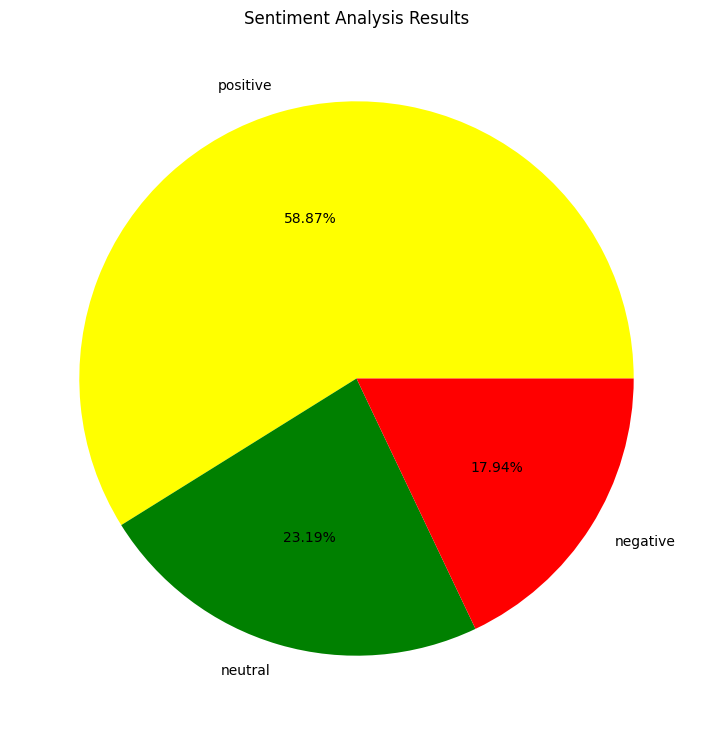

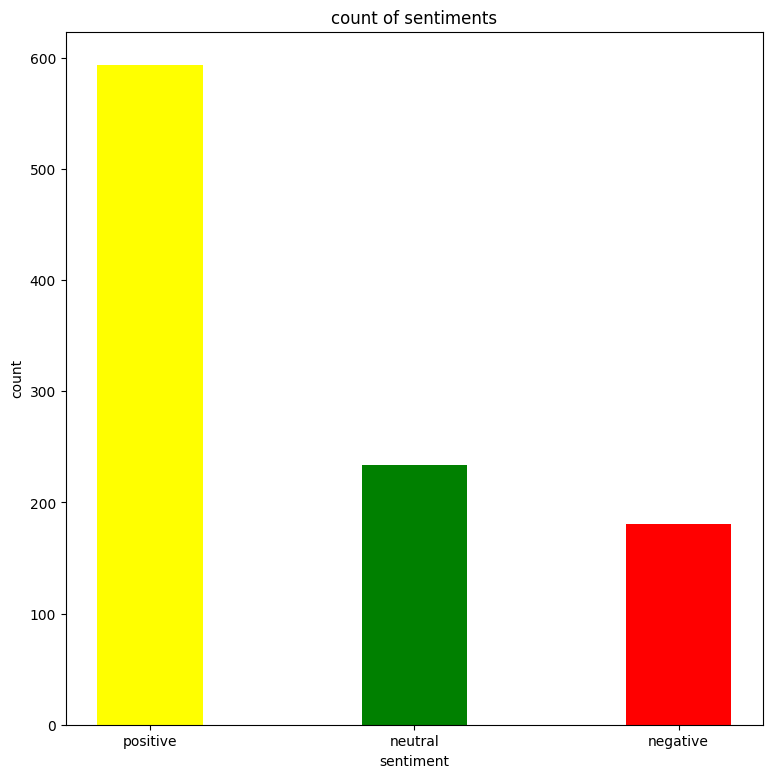

In [ ]:
#load csv with sentiment
df_sentiment = pd.read_csv('sentiment_2023.csv')

#count the amount of each sentiment
sentiment_counts = df_sentiment['sentiment'].value_counts()

#create pie diagram of sentiment percentages
plt.figure(figsize=(9, 9))
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%.2f%%', colors=['yellow', 'green', 'red'])
plt.title('Sentiment Analysis Results')
plt.show()

#count the amount of each sentiment
sentiment_counts = df_sentiment['sentiment'].value_counts()

#make plot
plt.figure(figsize=(9, 9))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['yellow', 'green', 'red'], width = 0.4)
plt.xlabel('sentiment')
plt.ylabel('count')
plt.title('count of sentiments')

#save plot
plt.savefig('question_1.png')

#Ερώτημα 2


In [ ]:
#creation of TF-IDF matrix with data from file 'train_2023.tsv'

#load data from 'train_2019.tsv'
df_train = pd.read_csv('train_2023.tsv', sep = '\t')

#keep 'comments' column
comments = df_train['comments']

#create TfidfVectorizer
vectorizer = TfidfVectorizer()

#transform data from column 'comments' and this will be the tfidf_matrix
tfidf_matrix = vectorizer.fit_transform(comments)

#save TfidfVectorizer to a pickle file named 'tfidf_vectorizer_2023.pkl'
with open('tfidf_vectorizer_2023.pkl', 'wb') as file:
  pickle.dump(vectorizer, file)

In [ ]:
#creation of wordembeddings with data of file 'train_2023.tsv'

#load data from 'train_2019.tsv'
df_train = pd.read_csv('train_2023.tsv', sep = '\t')

#keep 'comments' column
comments = df_train['comments']

#tokenize data from column 'comments'
tokenized_comments = [word_tokenize(com) for com in comments]

#create a Word2Vec model
model = Word2Vec(vector_size=100, window=5, min_count=1, workers=4)

model.build_vocab(tokenized_comments)
model.train(tokenized_comments, total_examples=model.corpus_count, epochs=model.epochs)

#save Word2Vec model to a pickle file named 'word2vec_model_2023.pkl'
with open('word2vec_model_2023.pkl', 'wb') as file:
  pickle.dump(model, file)

In [ ]:
#SVM with TF-IDF

#load data from 'train_2023.tsv'
df_train = pd.read_csv('train_2023.tsv', sep = '\t')

#keep 'sentiment' column
sentiment = df_train['sentiment']

#split
train_1, val_1, train_2, val_2 = train_test_split(tfidf_matrix, sentiment, test_size=0.2, random_state=42)

#train SVM classifier
clf = SVC(C=1.0, kernel='linear', gamma='scale')
clf.fit(train_1, train_2)

#print validation accuracy
print('Validation accuracy =', clf.score(val_1, val_2))

#load data from 'test_2023.tsv' transform comments to TF-IDF matrix, make predictions
df_test = pd.read_csv('test_2023.tsv', sep = '\t')
df_comm = df_test['comments']

#transform comments
with open('tfidf_vectorizer_2023.pkl', 'rb') as file:
  vectorizer = pickle.load(file)
test = vectorizer.transform(df_comm)

#make predictions
df_test['sentiment'] = clf.predict(test)

#save data with predictions
df_test.to_csv('predict_svm_tfidf.csv', index=False)

Validation accuracy = 0.7592592592592593


In [ ]:
#SVM with wordembeddings

#load Word2Vec model
with open('word2vec_model_2023.pkl', 'rb') as file:
  model = pickle.load(file)

#convert tokenized comments into vectors
vectorized_comments = [model.wv[comment] for comment in tokenized_comments]

#take the average of vectors for every comment to get a single vector for each comment
vectorized_comments = [np.mean(comment, axis=0) for comment in vectorized_comments]

#load data from 'train_2023.tsv'
df_train = pd.read_csv('train_2023.tsv', sep='\t')

#take 'sentiment' column
sentiment = df_train['sentiment']

#split
train_1, val_1, train_2, val_2 = train_test_split(vectorized_comments, sentiment, test_size=0.2, random_state=42)

#train SVM classifier
clf = SVC(C=1.0, kernel='linear', gamma='scale')
clf.fit(train_1, train_2)

#print validation accuracy
accuracy = clf.score(val_1, val_2)
print('Validation Accuracy:', accuracy)

#load data from 'test_2023.tsv'
df_test = pd.read_csv('test_2023.tsv', sep='\t')
df_test['comments'] = df_test['comments'].str.replace('\'', '').str.replace('[', '').str.replace(']', '').str.replace(',', '')

#take the 'comments' column
comments = df_test['comments']

#list so we can save word vectors
word_vectors_list = []

#go to every comment
for comment in comments:
  words = comment.split()
  word_vectors = [model.wv[word] for word in words if word in model.wv]
  if word_vectors:
    word_vectors_list.append(np.mean(word_vectors, axis=0))
  else:
    word_vectors_list.append(np.zeros(model.vector_size))

#convert list with word vectors to a numpy array
word_vectors_array = np.array(word_vectors_list)

#make sure the array is 2D
#if word_vectors_list.ndim == 1:
    #word_vectors_list = word_vectors_list.reshape(1, -1)

#use trained SVM classifier to predict sentiments on 'test_2019.tsv'
predictions = clf.predict(word_vectors_array)

#add predictions in DataFrame
df_test['sentiment'] = predictions

#save DataFrame to a new csv file
df_test.to_csv('predict_svm_word.csv', index=False)

Validation Accuracy: 0.6790123456790124


In [ ]:
#10-fold Cross Validation with TF-IDF for SVM

#load data from 'sentiment_2023_test.csv'
df = pd.read_csv('sentiment_2023_test.csv')

#transform comments
with open('tfidf_vectorizer_2023.pkl', 'rb') as file:
  vectorizer = pickle.load(file)

vec_comments = vectorizer.transform(df['comments'])
labels = LabelEncoder().fit_transform(df['sentiment'])

#initialize classifier and strategy for Cross Validation
clf = SVC(C=1.0, kernel='linear', gamma='scale')
cv = StratifiedKFold(n_splits=10)

#create dictionary named metrics and their scoring functions
metrics = {
  'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
  'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
  'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
  'Accuracy': 'accuracy'
}

#compute all scores for Cross Validation
scores = {metric: cross_val_score(clf, vec_comments, labels, cv=cv, scoring=scorer) for metric, scorer in metrics.items()}

#create DataFrame with all scores and print it
df_scores = pd.DataFrame(scores)
print(df_scores)

#print all metrics by average
print("\nBy average:")
for metric, score in scores.items():
    print(f'{metric}: {score.mean()}')

   Precision    Recall  F_Measure  Accuracy
0   0.342857  0.571429   0.428571  0.571429
1   0.528947  0.650000   0.539516  0.650000
2   0.378947  0.600000   0.464516  0.600000
3   0.347368  0.550000   0.425806  0.550000
4   0.366667  0.550000   0.440000  0.550000
5   0.644737  0.700000   0.608125  0.700000
6   0.516667  0.650000   0.571429  0.650000
7   0.378947  0.600000   0.464516  0.600000
8   0.523529  0.650000   0.563218  0.650000
9   0.360000  0.600000   0.450000  0.600000

By average:
Precision: 0.43886672563762347
Recall: 0.6121428571428572
F_Measure: 0.4955698229514275
Accuracy: 0.6121428571428572


In [ ]:
#10-fold Cross Validation with wordembeddings for SVM

#load data from 'sentiment_2023_test.csv'
df = pd.read_csv('sentiment_2023_test.csv')

with open('word2vec_model_2023.pkl', 'rb') as file:
  vectorizer = pickle.load(file)

comments = df['comments']
labels = LabelEncoder().fit_transform(df['sentiment'])

#create list to save embeddings
embeddings = []

#go to every comment
for comment in comments:
  words = comment.split()
  #initialize list to save word embeddings for each comment
  word_embeddings_list = []
  #go to every word for each comment
  for word in words:
    #check if word is in vocabulary of word embeddings
    if word in vectorizer.wv:
      #append word's embedding to list with embeddings of each comment
      word_embeddings_list.append(vectorizer.wv[word])

  if word_embeddings_list:
    #compute mean embedding of words in each comment
    mean_embedding = np.mean(word_embeddings_list, axis=0)
  else:
    #create a vector with zeroes if comment has not words in vocabulary
    mean_embedding = np.zeros(vectorizer.wv.vector_size)

  #append mean embedding of each comment to list
  embeddings.append(mean_embedding)

#convert list with embeddings to a numpy array
embeddings_array = np.array(embeddings)

#initialize classifier and strategy for Cross Validation
clf= SVC(C=1.0, kernel='linear', gamma='scale')
cv = StratifiedKFold(n_splits=10)

#create dictionary named metrics and their scoring functions
metrics = {
  'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
  'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
  'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
  'Accuracy': 'accuracy'
}

#compute all scores for Cross Validation
scores = {metric: cross_val_score(clf, embeddings_array, labels, cv=cv, scoring=scorer) for metric, scorer in metrics.items()}

#create DataFrame with all scores and print it
df_scores = pd.DataFrame(scores)
print(df_scores)

#print all metrics by average
print("\nBy average:")
for metric, score in scores.items():
    print(f'{metric}: {score.mean()}')

   Precision    Recall  F_Measure  Accuracy
0   0.326531  0.571429   0.415584  0.571429
1   0.360000  0.600000   0.450000  0.600000
2   0.378947  0.600000   0.464516  0.600000
3   0.360000  0.600000   0.450000  0.600000
4   0.378947  0.600000   0.464516  0.600000
5   0.422500  0.650000   0.512121  0.650000
6   0.360000  0.600000   0.450000  0.600000
7   0.360000  0.600000   0.450000  0.600000
8   0.360000  0.600000   0.450000  0.600000
9   0.360000  0.600000   0.450000  0.600000

By average:
Precision: 0.3666925349087003
Recall: 0.6021428571428571
F_Measure: 0.45567378857701435
Accuracy: 0.6021428571428571


In [ ]:
#Random Forests with TF-IDF

#load data from 'train_2023.tsv'
df_train = pd.read_csv('train_2023.tsv', sep = '\t')

#keep 'sentiment' column
sentiment = df_train['sentiment']

#split
train_1, val_1, train_2, val_2 = train_test_split(tfidf_matrix, sentiment, test_size=0.2, random_state=42)

#train Random Forest classifier
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(train_1, train_2)

#print validation accuracy
print('Validation accuracy =', clf_rf.score(val_1, val_2))

#load data from 'test_2023.tsv' transform comments to TF-IDF matrix, make predictions
df_test = pd.read_csv('test_2023.tsv', sep = '\t')
df_comm = df_test['comments']

#transform comments
with open('tfidf_vectorizer_2023.pkl', 'rb') as file:
  vectorizer = pickle.load(file)
test = vectorizer.transform(df_comm)

#make predictions
df_test['sentiment'] = clf_rf.predict(test)

#save data with predictions
df_test.to_csv('predict_rf_tfidf.csv', index=False)

Validation accuracy = 0.7283950617283951


In [ ]:
#Random Forests with wordembeddings

#load Word2Vec model
with open('word2vec_model_2023.pkl', 'rb') as file:
  model = pickle.load(file)

#convert tokenized comments into vectors
vectorized_comments = [model.wv[comment] for comment in tokenized_comments]

#take the average of vectors for every comment to get a single vector for each comment
vectorized_comments = [np.mean(comment, axis=0) for comment in vectorized_comments]

#load data from 'train_2023.tsv'
df_train = pd.read_csv('train_2023.tsv', sep='\t')

#take 'sentiment' column
sentiment = df_train['sentiment']

#split
train_1, val_1, train_2, val_2 = train_test_split(vectorized_comments, sentiment, test_size=0.2, random_state=42)

#train Random Forest classifier
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(train_1, train_2)

#print validation accuracy
accuracy = clf_rf.score(val_1, val_2)
print('Validation Accuracy:', accuracy)

#load data from 'test_2023.tsv'
df_test = pd.read_csv('test_2023.tsv', sep='\t')
df_test['comments'] = df_test['comments'].str.replace('\'', '').str.replace('[', '').str.replace(']', '').str.replace(',', '')

#take the 'comments' column
comments = df_test['comments']

#list so we can save word vectors
word_vectors_list = []

#go to every comment
for comment in comments:
  words = comment.split()
  word_vectors = [model.wv[word] for word in words if word in model.wv]
  if word_vectors:
    word_vectors_list.append(np.mean(word_vectors, axis=0))
  else:
    word_vectors_list.append(np.zeros(model.vector_size))

#convert list with word vectors to a numpy array
word_vectors_array = np.array(word_vectors_list)

#make sure the array is 2D
#if word_vectors_list.ndim == 1:
    #word_vectors_list = word_vectors_list.reshape(1, -1)

#use trained SVM classifier to predict sentiments on 'test_2019.tsv'
predictions = clf_rf.predict(word_vectors_array)

#add predictions in DataFrame
df_test['sentiment'] = predictions

#save DataFrame to a new csv file
df_test.to_csv('predict_rf_word.csv', index=False)

Validation Accuracy: 0.7037037037037037


In [ ]:
#10-fold Cross Validation with TF-IDF for Random Forests

#load data from 'sentiment_2023_test.csv'
df = pd.read_csv('sentiment_2023_test.csv')

#transform comments
with open('tfidf_vectorizer_2023.pkl', 'rb') as file:
  vectorizer = pickle.load(file)

vec_comments = vectorizer.transform(df['comments'])
labels = LabelEncoder().fit_transform(df['sentiment'])

#initialize classifier and strategy for Cross Validation
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=10)

#create dictionary named metrics and their scoring functions
metrics = {
  'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
  'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
  'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
  'Accuracy': 'accuracy'
}

#compute all scores for Cross Validation
scores = {metric: cross_val_score(clf_rf, vec_comments, labels, cv=cv, scoring=scorer) for metric, scorer in metrics.items()}

#create DataFrame with all scores and print it
df_scores = pd.DataFrame(scores)
print(df_scores)

#print all metrics by average
print("\nBy average:")
for metric, score in scores.items():
    print(f'{metric}: {score.mean()}')

   Precision    Recall  F_Measure  Accuracy
0   0.342857  0.571429   0.428571  0.571429
1   0.528947  0.650000   0.539516  0.650000
2   0.650000  0.700000   0.622857  0.700000
3   0.360000  0.600000   0.450000  0.600000
4   0.554902  0.650000   0.580172  0.650000
5   0.533333  0.650000   0.569892  0.650000
6   0.578947  0.650000   0.544516  0.650000
7   0.745833  0.700000   0.665714  0.700000
8   0.716667  0.700000   0.651429  0.700000
9   0.360000  0.600000   0.450000  0.600000

By average:
Precision: 0.5371487173816896
Recall: 0.6471428571428571
F_Measure: 0.5502668573547328
Accuracy: 0.6471428571428571


In [ ]:
#10-fold Cross Validation with wordembeddings for Random Forests

#load data from 'sentiment_2023_test.csv'
df = pd.read_csv('sentiment_2023_test.csv')

with open('word2vec_model_2023.pkl', 'rb') as file:
  vectorizer = pickle.load(file)

comments = df['comments']
labels = LabelEncoder().fit_transform(df['sentiment'])

#create list to save embeddings
embeddings = []

#go to every comment
for comment in comments:
  words = comment.split()
  #initialize list to save word embeddings for each comment
  word_embeddings_list = []
  #go to every word for each comment
  for word in words:
    #check if word is in vocabulary of word embeddings
    if word in vectorizer.wv:
      #append word's embedding to list with embeddings of each comment
      word_embeddings_list.append(vectorizer.wv[word])

  if word_embeddings_list:
    #compute mean embedding of words in each comment
    mean_embedding = np.mean(word_embeddings_list, axis=0)
  else:
    #create a vector with zeroes if comment has not words in vocabulary
    mean_embedding = np.zeros(vectorizer.wv.vector_size)

  #append mean embedding of each comment to list
  embeddings.append(mean_embedding)

#convert list with embeddings to a numpy array
embeddings_array = np.array(embeddings)

#initialize classifier and strategy for Cross Validation
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=10)

#create dictionary named metrics and their scoring functions
metrics = {
    'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
    'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
    'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
    'Accuracy': 'accuracy'
}

#compute all scores for Cross Validation
scores = {metric: cross_val_score(clf_rf, embeddings_array, labels, cv=cv, scoring=scorer) for metric, scorer in metrics.items()}

#create DataFrame with all scores and print it
df_scores = pd.DataFrame(scores)
print(df_scores)

#print all metrics by average
print("\nBy average:")
for metric, score in scores.items():
    print(f'{metric}: {score.mean()}')

   Precision    Recall  F_Measure  Accuracy
0   0.488796  0.571429   0.501525  0.571429
1   0.823529  0.750000   0.714409  0.750000
2   0.628947  0.650000   0.547849  0.650000
3   0.366667  0.550000   0.440000  0.550000
4   0.610000  0.550000   0.542857  0.550000
5   0.500000  0.550000   0.521429  0.550000
6   0.588235  0.600000   0.535172  0.600000
7   0.585714  0.600000   0.582051  0.600000
8   0.723529  0.700000   0.643218  0.700000
9   0.375000  0.500000   0.428571  0.500000

By average:
Precision: 0.5690417956656346
Recall: 0.6021428571428571
F_Measure: 0.5457082306696959
Accuracy: 0.6021428571428571


In [ ]:
#KNN with TF-IDF

#load data from 'train_2023.tsv'
df_train = pd.read_csv('train_2023.tsv', sep = '\t')

#keep 'sentiment' column
sentiment = df_train['sentiment']

#split
train_1, val_1, train_2, val_2 = train_test_split(tfidf_matrix, sentiment, test_size=0.2, random_state=42)

#train KNN classifier
clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_knn.fit(train_1, train_2)

#print validation accuracy
print('Validation accuracy =', clf_knn.score(val_1, val_2))

#load data from 'test_2023.tsv' transform comments to TF-IDF matrix, make predictions
df_test = pd.read_csv('test_2023.tsv', sep = '\t')
df_comm = df_test['comments']

#transform comments
with open('tfidf_vectorizer_2023.pkl', 'rb') as file:
  vectorizer = pickle.load(file)
test = vectorizer.transform(df_comm)

#make predictions
df_test['sentiment'] = clf_knn.predict(test)

#save data with predictions
df_test.to_csv('predict_knn_tfidf.csv', index=False)

Validation accuracy = 0.808641975308642


In [ ]:
#KNN with wordembeddings

#load Word2Vec model
with open('word2vec_model_2023.pkl', 'rb') as file:
  model = pickle.load(file)

#convert tokenized comments into vectors
vectorized_comments = [model.wv[comment] for comment in tokenized_comments]

#take the average of vectors for every comment to get a single vector for each comment
vectorized_comments = [np.mean(comment, axis=0) for comment in vectorized_comments]

#load data from 'train_2023.tsv'
df_train = pd.read_csv('train_2023.tsv', sep='\t')

#take 'sentiment' column
sentiment = df_train['sentiment']

#split
train_1, val_1, train_2, val_2 = train_test_split(vectorized_comments, sentiment, test_size=0.2, random_state=42)

#train KNN classifier
clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_knn.fit(train_1, train_2)

#print validation accuracy
accuracy = clf_knn.score(val_1, val_2)
print('Validation Accuracy:', accuracy)

#load data from 'test_2023.tsv'
df_test = pd.read_csv('test_2023.tsv', sep='\t')
df_test['comments'] = df_test['comments'].str.replace('\'', '').str.replace('[', '').str.replace(']', '').str.replace(',', '')

#take the 'comments' column
comments = df_test['comments']

#list so we can save word vectors
word_vectors_list = []

#go to every comment
for comment in comments:
    words = comment.split()
    word_vectors = [model.wv[word] for word in words if word in model.wv]
    if word_vectors:
        word_vectors_list.append(np.mean(word_vectors, axis=0))
    else:
        word_vectors_list.append(np.zeros(model.vector_size))

#convert list with word vectors to a numpy array
word_vectors_array = np.array(word_vectors_list)

#make sure the array is 2D
#if word_vectors_list.ndim == 1:
    #word_vectors_list = word_vectors_list.reshape(1, -1)

#use trained SVM classifier to predict sentiments on 'test_2019.tsv'
predictions = clf_knn.predict(word_vectors_array)

#add predictions in DataFrame
df_test['sentiment'] = predictions

#save DataFrame to a new csv file
df_test.to_csv('predict_knn_word.csv', index=False)

Validation Accuracy: 0.6049382716049383


In [ ]:
#10-fold Cross Validation with TF-IDF for KNN

#load data from 'sentiment_2023_test.csv'
df = pd.read_csv('sentiment_2023_test.csv')

#transform comments
with open('tfidf_vectorizer_2023.pkl', 'rb') as file:
  vectorizer = pickle.load(file)

vec_comments = vectorizer.transform(df['comments'])
labels = LabelEncoder().fit_transform(df['sentiment'])

#train KNN classifier
clf_knn = KNeighborsClassifier(n_neighbors=5)
cv = StratifiedKFold(n_splits=10)

#create dictionary named metrics and their scoring functions
metrics = {
  'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
  'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
  'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
  'Accuracy': 'accuracy'
}

#compute all scores for Cross Validation
scores = {metric: cross_val_score(clf_knn, vec_comments, labels, cv=cv, scoring=scorer) for metric, scorer in metrics.items()}

#create DataFrame with all scores and print it
df_scores = pd.DataFrame(scores)
print(df_scores)

#print all metrics by average
print("\nBy average:")
for metric, score in scores.items():
    print(f'{metric}: {score.mean()}')

   Precision    Recall  F_Measure  Accuracy
0   0.444444  0.571429   0.482540  0.571429
1   0.880000  0.850000   0.826190  0.850000
2   0.463235  0.600000   0.515172  0.600000
3   0.462500  0.600000   0.521429  0.600000
4   0.508929  0.600000   0.550549  0.600000
5   0.546875  0.650000   0.593103  0.650000
6   0.711538  0.700000   0.701429  0.700000
7   0.823529  0.750000   0.709885  0.750000
8   0.550000  0.650000   0.580952  0.650000
9   0.366667  0.550000   0.440000  0.550000

By average:
Precision: 0.5757717849960496
Recall: 0.6521428571428571
F_Measure: 0.5921250052629363
Accuracy: 0.6521428571428571


In [ ]:
#10-fold Cross Validation with wordembeddings for KNN

#load data from 'sentiment_2023_test.csv'
df = pd.read_csv('sentiment_2023_test.csv')

with open('word2vec_model_2023.pkl', 'rb') as file:
  vectorizer = pickle.load(file)

comments = df['comments']
labels = LabelEncoder().fit_transform(df['sentiment'])

#create list to save embeddings
embeddings = []

#go to every comment
for comment in comments:
  words = comment.split()
  #initialize list to save word embeddings for each comment
  word_embeddings_list = []
  #go to every word for each comment
  for word in words:
    #check if word is in vocabulary of word embeddings
    if word in vectorizer.wv:
      #append word's embedding to list with embeddings of each comment
      word_embeddings_list.append(vectorizer.wv[word])

  if word_embeddings_list:
    #compute mean embedding of words in each comment
    mean_embedding = np.mean(word_embeddings_list, axis=0)
  else:
    #create a vector with zeroes if comment has not words in vocabulary
    mean_embedding = np.zeros(vectorizer.wv.vector_size)

  #append mean embedding of each comment to list
  embeddings.append(mean_embedding)

#convert list with embeddings to a numpy array
embeddings_array = np.array(embeddings)

#initialize classifier and strategy for Cross Validation
clf_knn = KNeighborsClassifier(n_neighbors=5)
cv = StratifiedKFold(n_splits=10)

#create dictionary named metrics and their scoring functions
metrics = {
  'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
  'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
  'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
  'Accuracy': 'accuracy'
}

#compute all scores for Cross Validation
scores = {metric: cross_val_score(clf_knn, embeddings_array, labels, cv=cv, scoring=scorer) for metric, scorer in metrics.items()}

#create DataFrame with all scores and print it
df_scores = pd.DataFrame(scores)
print(df_scores)

#print all metrics by average
print("\nBy average:")
for metric, score in scores.items():
    print(f'{metric}: {score.mean()}')

   Precision   Recall  F_Measure  Accuracy
0   0.483673  0.47619   0.462004   0.47619
1   0.817500  0.80000   0.775000   0.80000
2   0.388235  0.55000   0.455172   0.55000
3   0.375000  0.50000   0.428571   0.50000
4   0.503333  0.40000   0.444318   0.40000
5   0.516667  0.50000   0.507143   0.50000
6   0.578205  0.60000   0.587143   0.60000
7   0.556667  0.55000   0.551587   0.55000
8   0.621429  0.65000   0.624359   0.65000
9   0.375000  0.50000   0.428571   0.50000

By average:
Precision: 0.5215709129805768
Recall: 0.5526190476190476
F_Measure: 0.526386904784688
Accuracy: 0.5526190476190476


Για τον SVM παρατηρώ ότι η πιο αποδοτική μέθοδος είναι με TF-IDF. Για τον Random Forests η πιο αποδοτική μέθοδος εξαρτάται από τα δεδομένα διότι και οι δύο είναι πολύ κοντά. Για τον KNN η πιο αποδοτική μέθοδος είναι με TF-IDF. Συνολικά η πιο αποδοτική μέθοδος είναι με TF-IDF και classifier τον KNN.

#Ερώτημα 3

In [ ]:
#load Word2Vec model
with open('word2vec_model_2023.pkl', 'rb') as file:
  model = pickle.load(file)

#function for calculating similarity with cosine method
#def similarity(vector1, vector2):
  #sim = 1 - cosine(vector1, vector2)
  #return sim

#EROTIMA 3a
#function for finding the semantic neighborhood of a word
def semantic_neighborhood(word, N, famous_words):
  #take lots of neighboring words
  similar_words = model.wv.most_similar(word, topn=(N*100000))
  neighborhood = list()
  for temp, _ in similar_words:
    #each neighboring word must be in the vocabulary
    if temp in famous_words:
      neighborhood.append(temp)
  #keep first N words for neighborhood
  if len(neighborhood) > N:
    neighborhood = neighborhood[:N]
  return neighborhood

#EROTIMA 3b(a)
#function for calculating similarity according to maximum similarity of neighborhoods
def maximum_similarity_of_neighborhoods(word1, word2, neighborhood1, neighborhood2, sim_array, famous_words):
  maximum_similarity = -99999
  maximum_similarity_1 = -99999
  maximum_similarity_2 = -99999
  for wordneigh1 in neighborhood1:
    sim = sim_array[famous_words.index(wordneigh1)][famous_words.index(word2)]
    if sim > maximum_similarity_2:
      maximum_similarity_2 = sim
  for wordneigh2 in neighborhood2:
    sim = sim_array[famous_words.index(wordneigh2)][famous_words.index(word1)]
    if sim > maximum_similarity_1:
      maximum_similarity_1 = sim
  if maximum_similarity_1 > maximum_similarity_2:
    maximum_similarity = maximum_similarity_1
  else:
    maximum_similarity = maximum_similarity_2
  return maximum_similarity

#EROTIMA 3b(b)
#function for calculating similarity according to correlation of neighborhood similarities
def correlation_of_neighborhood_similarities(word1, word2, neighborhood1, neighborhood2, sim_array, famous_words):
  similarities1_1 = list()
  similarities1_2 = list()
  similarities2_1 = list()
  similarities2_2 = list()
  for wordneigh1 in neighborhood1:
    if wordneigh1 != word1:
      similarities1_1.append(sim_array[famous_words.index(word1)][famous_words.index(wordneigh1)])
  for wordneigh2 in neighborhood2:
    similarities1_2.append(sim_array[famous_words.index(word1)][famous_words.index(wordneigh2)])
  for wordneigh1 in neighborhood1:
    similarities2_1.append(sim_array[famous_words.index(word2)][famous_words.index(wordneigh1)])
  for wordneigh2 in neighborhood2:
    if wordneigh2 != word2:
      similarities2_2.append(sim_array[famous_words.index(word2)][famous_words.index(wordneigh2)])
  correlation_1 = np.corrcoef(similarities1_1, similarities2_1)[0, 1]
  correlation_2 = np.corrcoef(similarities1_2, similarities2_2)[0, 1]
  if correlation_1 > correlation_2:
    correlation = correlation_1
  else:
    correlation = correlation_2
  return correlation

#EROTIMA 3b(c)
#function for calculating the similarity according to sum of squared neighborhood similarities
def sum_of_squared_neighborhood_similarities(neighborhood1, neighborhood2, sim_array, famous_words):
  total_sum = 0
  total_sum_1 = 0
  total_sum_2 = 0
  for wordneigh2 in neighborhood2:
    sim_1 = sim_array[famous_words.index(word1)][famous_words.index(wordneigh2)]
    total_sum_1 = total_sum_1 + sim_1 ** 2
  for wordneigh1 in neighborhood1:
    sim_2 = sim_array[famous_words.index(word2)][famous_words.index(wordneigh1)]
    total_sum_2 = total_sum_2 + sim_2 ** 2
  total_sum = total_sum_1 + total_sum_2
  sq = np.sqrt(total_sum)
  return sq

df_train = pd.read_csv('train_2023.csv')
df_train['comments'] = df_train['comments'].str.replace('\'', '').str.replace('[', '').str.replace(']', '').str.replace(',', '')
all_words = []
comments = df_train['comments'].str.split()
for comment in comments:
  for word in comment:
    all_words.append(word)

#count how many times a word exists
frequency_words = Counter(all_words)
#keep 300 most common as asked
famous = dict(frequency_words.most_common(300))
vec_list = []
for word in list(famous.keys()):
  #check if each word is in vocabulary
  if word in model.wv:
    vec_list.append(model.wv[word])
vec_array = np.array(vec_list)
#create similarity matrix
sim_array = cosine_similarity(vec_array)

while True:
  N = int(input("Give parameter N: "))
  if N == -1:
    break
  word1 = input('Give first word: ')
  word2 = input('Give second word: ')

  if word1 in famous.keys() and word2 in famous.keys():
    neighborhood1 = semantic_neighborhood(word1, N, list(famous.keys()))
    neighborhood2 = semantic_neighborhood(word2, N, list(famous.keys()))
    maximum_similarity = maximum_similarity_of_neighborhoods(word1, word2, neighborhood1, neighborhood2, sim_array, list(famous.keys()))
    correlation_similarity = correlation_of_neighborhood_similarities(word1, word2, neighborhood1, neighborhood2, sim_array, list(famous.keys()))
    squared_similarity = sum_of_squared_neighborhood_similarities(neighborhood1, neighborhood2, sim_array, list(famous.keys()))
    similarity_dict = dict()
    similarity_dict['maximum_similarity_of_neighborhoods'] = maximum_similarity
    similarity_dict['correlation_of_neighborhood_similarities'] = correlation_similarity
    similarity_dict['sum_of_squared_neighborhood_similarities'] = squared_similarity
    print(f"{N} words neighborhood of word '{word1}' is {neighborhood1}")
    print(f"{N} words neighborhood of word '{word2}' is {neighborhood2}")
    print(similarity_dict)
  else:
    print('There is a word out of vocabulary. Try again.')


Give parameter N: 10
Give first word: arrival
Give second word: place
10 words neighborhood of word 'arrival' is ['day', 'host', 'reservation', 'late', 'last', 'found', 'full', 'next', 'although', 'hotel']
10 words neighborhood of word 'place' is ['apartment', 'night', 'even', 'bed', 'get', 'building', 'area', 'athens', 'br', 'one']
{'maximum_similarity_of_neighborhoods': 0.999259, 'correlation_of_neighborhood_similarities': 0.023568614219689636, 'sum_of_squared_neighborhood_similarities': 4.3584001122152385}
Give parameter N: 6
Give first word: although
Give second word: building
6 words neighborhood of word 'although' is ['night', 'room', 'find', 'area', 'building', 'issue']
6 words neighborhood of word 'building' is ['place', 'night', 'apartment', 'one', 'room', 'nice']
{'maximum_similarity_of_neighborhoods': 0.9999997, 'correlation_of_neighborhood_similarities': -0.0171115238335029, 'sum_of_squared_neighborhood_similarities': 3.4612849353625683}
Give parameter N: 2
Give first word:

Παρατηρώ ότι το maximum_similarity_of_neighborhoods παραμένει παρόμοιο σε κάθε τιμή του Ν διότι ψάχνει τη μέγιστη τιμή του similarity. Όσο αυξάνεται το Ν, αυξάνεται και το sum_of_squared_neighborhood_similarities αφού υπολογίζει άθροισμα κι έτσι λαμβάνει υπόψιν του περισσότερες λέξεις. Όσον αφορά το correlation_of_neighborhood_similarities, όσο αυξάνεται η τιμή του Ν μπορεί να μπουν στη γειτονιά μίας λέξης, words με μεγάλη ομοιότητα αφού αλλά μπορεί να μπουν και words με χαμηλή ομοιότητα με την αρχική λέξη. Επομένως το πώς επηρεάζει η αλλαγή του Ν την τιμή του correlation_of_neighborhood_similarities εξαρτάται από τα words που θα βρεθούν στη γειτονιά μίας λέξης.